In [11]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

1. $q$ and $\omega$ limits for different dm mass with $\omega_{th} = 1$ meV. $\omega_{max}$ depends on $q$, and only $\omega_{max}(q_+/2)$ is listed here. Changing $\omega_{th} = 1$ doesn't change the upper limits of $q$ and $\omega$ much. 
    - $m= 100$ keV: $q\in(0.0004, 0.49)$ keV, $\omega_{max} = 0.0003$ keV $ = 300 $ meV.
    - $m= 10^6$ keV $= 1$ GeV: $q\in(0.0004, 4939.0)$ keV, $\omega_{max} = 3$ keV $ = 3\times10^6$ meV. 

$\bar\omega = 13$ meV, DM mass range 100 keV ~ 10^6 keV 

In [12]:
class RateCalculations:
    def __init__(self, mass_DM, q_val, omega_list,omega_threshold,s_factor,cross_section):
        c = 2.998e5 #in km/s
        self.mass_DM = mass_DM
        self.mass_proton = 938.272e3 # keV
        self.density_DM = 0.3e6 # keV/cm^3, plus minus 0.1
        self.density_target = 1.307e30 # keV/cm^3 from silicon density of 2329.6 kg/m3
        self.v_esc = 500/c 
        self.v_earth = 240/c 
        self.v_disp = 220/c
        self.q_val = q_val
        self.omega_list = omega_list 
        self.s_factor = s_factor
        self.omega_threshold = omega_threshold # detector threshold. keV
        self.cross_section = cross_section # cm^2
        self.v_max = self.v_esc + self.v_earth 
        # unit conversion, ref: https://physics.nist.gov/cuu/Constants/energy.html
        self.keV2InvS = 2.418e17 # keV to 1/s
        self.year2sec = 86400. * 365.
        self.keV2InvYr = self.keV2InvS * self.year2sec
        self.keV2kg = 1.78e-33
        self.keV2InvCm = 8.065e6

    def get_v_min(self, mass_DM, q,):
        return self.omega_list/ q + q / (2 * mass_DM)
    
    def _inverse_mean_sol1(self, v_min):
        '''
        Helper function used in get_inverse_mean_func
        '''
        ratio = self.v_esc/self.v_disp
        norm_fac = (self.v_disp**3) * np.pi * (np.sqrt(np.pi) * sp.special.erf(ratio) - 2*ratio*np.exp(-ratio**2)) # 1904.07915 eqn 108
        vel_integral = (np.sqrt(np.pi) * self.v_disp * (sp.special.erf((v_min+self.v_earth)/self.v_disp) 
                                                       - sp.special.erf((v_min-self.v_earth)/self.v_disp))
                        - 4 * self.v_earth * np.exp(-ratio**2))   
        return self.v_disp**2 * np.pi / (2*self.v_earth*norm_fac) * vel_integral 

    def _inverse_mean_sol2(self,v_min): 
        '''
        Helper function used in get_inverse_mean_func
        '''
        ratio = self.v_esc/self.v_disp
        norm_fac = (self.v_disp**3) * np.pi * (np.sqrt(np.pi) * sp.special.erf(ratio) - 2*ratio*np.exp(-ratio**2))
        vel_integral = (np.sqrt(np.pi) * self.v_disp * (sp.special.erf(ratio) 
                                                       - sp.special.erf((v_min-self.v_earth)/self.v_disp))
                        - 2 * (self.v_esc-v_min+self.v_earth) * np.exp(-ratio**2 ))   
        return self.v_disp**2 * np.pi / (2*self.v_earth*norm_fac) * vel_integral


    def get_inverse_mean_func(self,mass_DM, q,): # 1509.01598 appendix B
        '''
        returns: inverse mean function, 3d array with the same shape as v_min (num of DM mass, num of p, num of omega)
        '''
        v_min = self.get_v_min(mass_DM, q)
        return np.where(v_min>(self.v_esc+self.v_earth), 0., 
                        np.where(v_min<(self.v_esc-self.v_earth),
                                self._inverse_mean_sol1(v_min),
                                self._inverse_mean_sol2(v_min)))
    
    
    def _get_omega_mask(self,):
        omega_max = self.q_val * self.v_max - self.q_val**2 / (2 * self.mass_DM)
        return (self.omega_list > self.omega_threshold) & (self.omega_list < omega_max)

    
    def get_diff_rate_dRdq(self, ): # 2108.03239 eqn 11
        reducedMass = self.mass_DM * self.mass_proton/(self.mass_DM + self.mass_proton)
        constFactor = self.density_DM * self.cross_section / (4* np.pi * self.density_target * self.mass_DM * reducedMass**2)
        omega_mask = self._get_omega_mask()
        if np.sum(omega_mask)<2: 
            return 0.
        else:
            integrand = self.get_inverse_mean_func(self.mass_DM,self.q_val) * self.s_factor * self.q_val
            return constFactor * sp.integrate.simpson(integrand[omega_mask], self.omega_list[omega_mask]) * self.keV2InvCm**2 * self.keV2InvYr / self.keV2kg # per kg-year-keV


In [13]:
def get_impulse_approx(q, omega_list, omega_avg=30e-6, ):
    mass=26161e3 # sillicon, keV
    latticeConst= 2*np.pi/2.28 # si, keV^-3
    deltasq = q**2 * omega_avg/(2*mass)
    return 28**2 / ((latticeConst**3)/4) * np.sqrt(2*np.pi/deltasq) * np.exp(- (omega_list-(q**2/(2*mass)))**2 / (2*deltasq)) # uses averaged omega (not inverse of averaged inverse)


$$q_\pm \equiv m_\chi v \bigg(1\pm \sqrt{1-\frac{2\omega_{th}}{m_\chi v^2}}\bigg) $$
$$\omega_+ \equiv qv -\frac{q^2}{2m_\chi}$$

In [14]:
def get_q_lim(mass_DM, omega_threshold=10e-6):
    v_max = 0.00247 # in c
    q_min = mass_DM * v_max * (1 - np.sqrt(1-2*omega_threshold/(mass_DM * (v_max**2))))
    q_max = mass_DM * v_max * (1 + np.sqrt(1-2*omega_threshold/(mass_DM * (v_max**2))))
    return  q_min, q_max

def get_omega_lim(mass_DM, q,): 
    v_max = 0.00247 # in c
    return q * v_max - q**2 / (2 * mass_DM)


In [15]:
omega_threshold = 1e-6 # keV
cross_section = 1e-40 # cm^2
omega_avg = 13.13e-6

In [16]:
# dmmasslist_4plot = np.array([1e3, 40e3, 100e3, 1e6]) # 1 MeV, 40 MeV, 100 MeV, 1 GeV
# dRdq_result_4plot = []
# qlist_4plot = []
# for dmmass in dmmasslist_4plot:
#     omega_length=6000
#     q_length=6000
#     qlist = np.linspace(*get_q_lim(dmmass, omega_threshold), q_length)
#     dRdq_result = np.empty(q_length)
#     for ind_q, q in enumerate(qlist): 
#         omega_max = get_omega_lim(dmmass, q)
#         omegalist = np.linspace(omega_threshold,omega_max , omega_length)
#         s_factor_ia = get_impulse_approx(q, omegalist, omega_avg,)
#         rateCal = RateCalculations(dmmass, q, omegalist, omega_threshold, s_factor_ia, cross_section)
#         dRdq_result[ind_q] = rateCal.get_diff_rate_dRdq()
#     dRdq_result_4plot.append(dRdq_result)
#     qlist_4plot.append(qlist)

In [17]:
nSiteData = np.load("testMultiprocess.npz")
s_factor_nSite = nSiteData["final_results"]
q_list_nSite = nSiteData["qlist"]
omega_list_nSite = nSiteData["omegalist"]

In [ ]:
dm_length = 200
dmmasslist = 10**np.linspace(2, 6, dm_length) # 10^3 ~ 10^6 keV, = 1MeV ~ 1GeV


rate_result = np.empty(dm_length)
for ind_m, dmmass in enumerate(dmmasslist):    
    if ind_m%10 == 0: print(f'processing {ind_m}...')
    q_min, q_max = get_q_lim(dmmass, omega_threshold)
    if q_max < q_list_nSite[-1]:
        qlist = q_list_nSite
        dRdq_result = np.empty(len(q_list_nSite))
        for ind_q, q in enumerate(qlist): 
            rateCal = RateCalculations(dmmass, q, omega_list_nSite, omega_threshold, s_factor_nSite[ind_q], cross_section)
            dRdq_result[ind_q] = rateCal.get_diff_rate_dRdq()
    else: 
        omega_length=2000
        q_length=1000
        qlist = np.concatenate((q_list_nSite, np.linspace(q_list_nSite[-1], q_max, q_length+1)[1:]))
        dRdq_result = np.empty(q_length+len(q_list_nSite))
        for ind_q, q in enumerate(qlist): 
            omega_max = get_omega_lim(dmmass, q)
            omegalist = np.linspace(omega_threshold,omega_max , omega_length)
            s_factor_ia = get_impulse_approx(q, omegalist, omega_avg=omega_avg,)
            rateCal = RateCalculations(dmmass, q, omegalist, omega_threshold, s_factor_ia, cross_section)
            dRdq_result[ind_q] = rateCal.get_diff_rate_dRdq()
    rate_result[ind_m] = sp.integrate.simpson(dRdq_result, qlist) # per kg-year
    

processing 0...
processing 10...
processing 20...
processing 30...
processing 40...
processing 50...
processing 60...
processing 70...
processing 80...
processing 90...
processing 100...
processing 110...
processing 120...
processing 130...
processing 140...
processing 150...
processing 160...
processing 170...
processing 180...
processing 190...


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


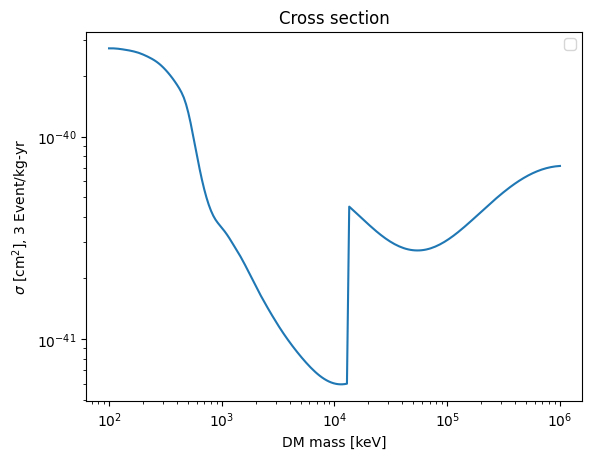

In [19]:
plt.plot(dmmasslist, 3*cross_section/rate_result, )
plt.title('Cross section')
plt.ylabel("$\sigma$ [cm$^2$], 3 Event/kg-yr")
plt.xlabel('DM mass [keV]')
plt.yscale('log')
plt.xscale('log')
plt.legend()

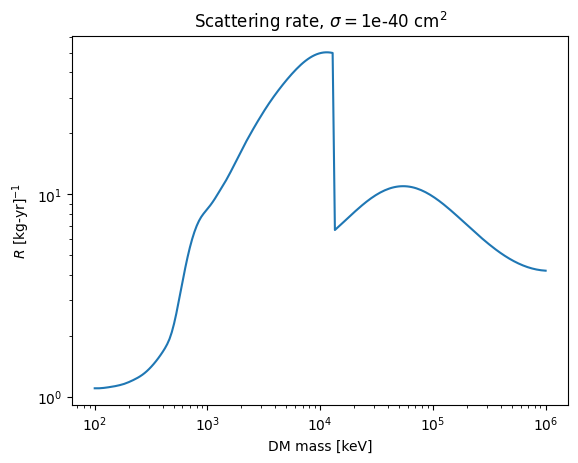

In [20]:
plt.plot(dmmasslist, rate_result,)
plt.title(f'Scattering rate, $\sigma = ${cross_section} cm$^2$')
plt.ylabel("$R$ [kg-yr]$^{-1}$")
plt.xlabel('DM mass [keV]')
plt.yscale('log')
plt.xscale('log')